# Data Collection
## Clean Finance Data

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
FINANCIAL_PANEL_FILE = OUTPUT_DIR + "financial_returns_and_controls.parquet"
FINANCIAL_PANEL_CSV = OUTPUT_DIR + "financial_returns_and_controls.csv"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"


## 1. Load Raw Data

In [13]:
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Basic cleaning: parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    # Adjust here if your date column has a different name
    raise KeyError("Expected a 'Date_' column. Please adjust the code to your date column name.")

print(df_raw.head())
print(df_raw.info())

            Close_AAPL  Close_BTC-USD  Close_CL=F  Close_CNY=X  Close_EUR=X  \
Date_                                                                         
2024-01-29         NaN            NaN         NaN          NaN          NaN   
2024-01-30    186.2807     42952.6094     77.8200       7.0845       0.9230   
2024-01-31    182.6748     42582.6055     75.8500       7.0941       0.9222   
2024-02-01    185.1118     43075.7734     73.8200       7.1007       0.9256   
2024-02-02    184.1113     43185.8594     72.2800       7.0885       0.9196   

            Close_GC=F  Close_^GSPC  Close_^SP500-101020  Close_^SP500-201060  \
Date_                                                                           
2024-01-29         NaN          NaN                  NaN                  NaN   
2024-01-30   2031.5000    4924.9702             727.8600            2007.1600   
2024-01-31   2048.3999    4845.6499             714.2100            1982.2800   
2024-02-01   2053.0000    4906.1899      

## 2. Rename columns

In [14]:
# Inspect available columns
df_raw.columns

Index(['Close_AAPL', 'Close_BTC-USD', 'Close_CL=F', 'Close_CNY=X',
       'Close_EUR=X', 'Close_GC=F', 'Close_^GSPC', 'Close_^SP500-101020',
       'Close_^SP500-201060', 'Close_^SP500-2510', 'Close_^SP500-452030',
       'Close_^TNX', 'High_AAPL', 'High_BTC-USD', 'High_CL=F', 'High_CNY=X',
       'High_EUR=X', 'High_GC=F', 'High_^GSPC', 'High_^SP500-101020',
       'High_^SP500-201060', 'High_^SP500-2510', 'High_^SP500-452030',
       'High_^TNX', 'Low_AAPL', 'Low_BTC-USD', 'Low_CL=F', 'Low_CNY=X',
       'Low_EUR=X', 'Low_GC=F', 'Low_^GSPC', 'Low_^SP500-101020',
       'Low_^SP500-201060', 'Low_^SP500-2510', 'Low_^SP500-452030', 'Low_^TNX',
       'Open_AAPL', 'Open_BTC-USD', 'Open_CL=F', 'Open_CNY=X', 'Open_EUR=X',
       'Open_GC=F', 'Open_^GSPC', 'Open_^SP500-101020', 'Open_^SP500-201060',
       'Open_^SP500-2510', 'Open_^SP500-452030', 'Open_^TNX', 'Volume_AAPL',
       'Volume_BTC-USD', 'Volume_CL=F', 'Volume_CNY=X', 'Volume_EUR=X',
       'Volume_GC=F', 'Volume_^GSPC', 'Volume

In [15]:
# Define a renaming map
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Open_BTC-USD": "open_btc",
    "High_BTC-USD": "high_btc",
    "Low_BTC-USD": "low_btc",
    "Volume_BTC-USD": "vol_btc",

    "Close_GC=F": "close_gold",
    "Open_GC=F": "open_gold",
    "High_GC=F": "high_gold",
    "Low_GC=F": "low_gold",
    "Volume_GC=F": "vol_gold",

    "Close_CL=F": "close_oil",
    "Open_CL=F": "open_oil",
    "High_CL=F": "high_oil",
    "Low_CL=F": "low_oil",
    "Volume_CL=F": "vol_oil",

    "Close_^GSPC": "close_spx",
    "Open_^GSPC": "open_spx",
    "High_^GSPC": "high_spx",
    "Low_^GSPC": "low_spx",
    "Volume_^GSPC": "vol_spx",

    "Close_CNY=X": "close_usdcny",
    "Open_CNY=X": "open_usdcny",
    "High_CNY=X": "high_usdcny",
    "Low_CNY=X": "low_usdcny",
    "Volume_CNY=X": "vol_usdcny",

    "Close_EUR=X": "close_eurusd",
    "Open_EUR=X": "open_eurusd",
    "High_EUR=X": "high_eurusd",
    "Low_EUR=X": "low_eurusd",
    "Volume_EUR=X": "vol_eurusd",

    "Close_^TNX": "close_ust10y",
    "Open_^TNX": "open_ust10y",
    "High_^TNX": "high_ust10y",
    "Low_^TNX": "low_ust10y",
    "Volume_^TNX": "vol_ust10y",

    "Close_^SP500-2510": "close_spx_auto",
    "Open_^SP500-2510": "open_spx_auto",
    "High_^SP500-2510": "high_spx_auto",
    "Low_^SP500-2510": "low_spx_auto",
    "Volume_^SP500-2510": "vol_spx_auto",

    "Close_^SP500-101020": "close_spx_oilgas",
    "Open_^SP500-101020": "open_spx_oilgas",
    "High_^SP500-101020": "high_spx_oilgas",
    "Low_^SP500-101020": "low_spx_oilgas",
    "Volume_^SP500-101020": "vol_spx_oilgas",

    "Close_^SP500-201060": "close_spx_mach",
    "Open_^SP500-201060": "open_spx_mach",
    "High_^SP500-201060": "high_spx_mach",
    "Low_^SP500-201060": "low_spx_mach",
    "Volume_^SP500-201060": "vol_spx_mach",

    "Close_^SP500-452030": "close_spx_elec",
    "Open_^SP500-452030": "open_spx_elec",
    "High_^SP500-452030": "high_spx_elec",
    "Low_^SP500-452030": "low_spx_elec",
    "Volume_^SP500-452030": "vol_spx_elec",

    "Close_AAPL": "close_aapl",
    "Open_AAPL": "open_aapl",
    "High_AAPL": "high_aapl",
    "Low_AAPL": "low_aapl",
    "Volume_AAPL": "vol_aapl",
}

df = df_raw.rename(columns=rename_map)

print("After renaming:")
print(df.head())


After renaming:
            close_aapl  close_btc  close_oil  close_usdcny  close_eurusd  \
Date_                                                                      
2024-01-29         NaN        NaN        NaN           NaN           NaN   
2024-01-30    186.2807 42952.6094    77.8200        7.0845        0.9230   
2024-01-31    182.6748 42582.6055    75.8500        7.0941        0.9222   
2024-02-01    185.1118 43075.7734    73.8200        7.1007        0.9256   
2024-02-02    184.1113 43185.8594    72.2800        7.0885        0.9196   

            close_gold  close_spx  close_spx_oilgas  close_spx_mach  \
Date_                                                                 
2024-01-29         NaN        NaN               NaN             NaN   
2024-01-30   2031.5000  4924.9702          727.8600       2007.1600   
2024-01-31   2048.3999  4845.6499          714.2100       1982.2800   
2024-02-01   2053.0000  4906.1899          713.5200       2021.1899   
2024-02-02   2036.1000  4

## 3. Align frequencies and handle non-trading days

We keep the native trading-day calendar (no synthetic weekend/holiday rows). Prices are forward-filled within existing rows only, and a flag marks rows that needed filling.

In [16]:
# Create a continuous business-day index over the sample
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

# Identify price and volume columns
price_cols = [c for c in df.columns if c.startswith(("close_", "open_", "high_", "low_"))]
volume_cols = [c for c in df.columns if c.startswith("vol_")]

# Track rows where prices were missing prior to forward-fill
missing_price_rows = df[price_cols].isna().any(axis=1)

# Forward-fill prices, leave volumes as-is
df[price_cols] = df[price_cols].ffill()

# Flag rows that relied on forward-filled prices
df["ffill_flag"] = missing_price_rows

print(df.head())

            close_aapl  close_btc  close_oil  close_usdcny  close_eurusd  \
2024-01-29         NaN        NaN        NaN           NaN           NaN   
2024-01-30    186.2807 42952.6094    77.8200        7.0845        0.9230   
2024-01-31    182.6748 42582.6055    75.8500        7.0941        0.9222   
2024-02-01    185.1118 43075.7734    73.8200        7.1007        0.9256   
2024-02-02    184.1113 43185.8594    72.2800        7.0885        0.9196   

            close_gold  close_spx  close_spx_oilgas  close_spx_mach  \
2024-01-29         NaN        NaN               NaN             NaN   
2024-01-30   2031.5000  4924.9702          727.8600       2007.1600   
2024-01-31   2048.3999  4845.6499          714.2100       1982.2800   
2024-02-01   2053.0000  4906.1899          713.5200       2021.1899   
2024-02-02   2036.1000  4958.6099          714.9000       2042.1500   

            close_spx_auto  ...  vol_usdcny  vol_eurusd   vol_gold  \
2024-01-29             NaN  ...         NaN   


## 4. Construct returns and control variables

We compute:

- **Absolute log returns** (volatility proxies) for Bitcoin, Gold, S&P 500.
- **Log differences** for FX and oil.
- **First difference** for the 10-year yield.


In [17]:
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns (absolute values for volatility prediction)
returns["r_btc"] = np.abs(log_return(df["close_btc"]))
returns["r_gold"] = np.abs(log_return(df["close_gold"]))
returns["r_spx"] = np.abs(log_return(df["close_spx"]))
returns["r_spx_auto"] = np.abs(log_return(df["close_spx_auto"]))
returns["r_spx_oilgas"] = np.abs(log_return(df["close_spx_oilgas"]))
returns["r_spx_mach"] = np.abs(log_return(df["close_spx_mach"]))
returns["r_spx_elec"] = np.abs(log_return(df["close_spx_elec"]))
returns["r_aapl"] = np.abs(log_return(df["close_aapl"]))

# Signed returns for trading strategies
returns["r_btc_signed"] = log_return(df["close_btc"])
returns["r_gold_signed"] = log_return(df["close_gold"])
returns["r_spx_signed"] = log_return(df["close_spx"])
returns["r_spx_auto_signed"] = log_return(df["close_spx_auto"])
returns["r_spx_oilgas_signed"] = log_return(df["close_spx_oilgas"])
returns["r_spx_mach_signed"] = log_return(df["close_spx_mach"])
returns["r_spx_elec_signed"] = log_return(df["close_spx_elec"])
returns["r_aapl_signed"] = log_return(df["close_aapl"])

# Control variables
returns["dln_eurusd"] = log_return(df["close_eurusd"])   # USD/EUR
returns["dln_usdcny"] = log_return(df["close_usdcny"])   # USD/CNY
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs from differencing
returns = returns.dropna()

# Restrict to analysis window
returns = returns.loc[START_DATE:END_DATE]

# Compute momentum indicators (1-day, 3-day, 5-day)
for asset in ["btc", "gold", "spx", "spx_auto", "spx_oilgas", "spx_mach", "spx_elec", "aapl"]:
    signed_col = f"r_{asset}_signed"
    returns[f"momentum_1d_{asset}"] = returns[signed_col].rolling(1).mean()
    returns[f"momentum_3d_{asset}"] = returns[signed_col].rolling(3).mean()
    returns[f"momentum_5d_{asset}"] = returns[signed_col].rolling(5).mean()

# Drop NaNs created by rolling windows
returns = returns.dropna()

print(f"Returns shape: {returns.shape}")
print(f"Columns: {list(returns.columns)}")
returns.head()


Returns shape: (104, 44)
Columns: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl', 'r_btc_signed', 'r_gold_signed', 'r_spx_signed', 'r_spx_auto_signed', 'r_spx_oilgas_signed', 'r_spx_mach_signed', 'r_spx_elec_signed', 'r_aapl_signed', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'momentum_1d_btc', 'momentum_3d_btc', 'momentum_5d_btc', 'momentum_1d_gold', 'momentum_3d_gold', 'momentum_5d_gold', 'momentum_1d_spx', 'momentum_3d_spx', 'momentum_5d_spx', 'momentum_1d_spx_auto', 'momentum_3d_spx_auto', 'momentum_5d_spx_auto', 'momentum_1d_spx_oilgas', 'momentum_3d_spx_oilgas', 'momentum_5d_spx_oilgas', 'momentum_1d_spx_mach', 'momentum_3d_spx_mach', 'momentum_5d_spx_mach', 'momentum_1d_spx_elec', 'momentum_3d_spx_elec', 'momentum_5d_spx_elec', 'momentum_1d_aapl', 'momentum_3d_aapl', 'momentum_5d_aapl']


,r_btc,r_gold,r_spx,r_spx_auto,r_spx_oilgas,r_spx_mach,r_spx_elec,r_aapl,r_btc_signed,r_gold_signed,...,momentum_5d_spx_oilgas,momentum_1d_spx_mach,momentum_3d_spx_mach,momentum_5d_spx_mach,momentum_1d_spx_elec,momentum_3d_spx_elec,momentum_5d_spx_elec,momentum_1d_aapl,momentum_3d_aapl,momentum_5d_aapl
2025-01-07,0.0518,0.0069,0.0112,0.0393,0.0104,0.0045,0.0034,0.0115,-0.0518,0.0069,...,0.0050,-0.0045,0.0026,-0.0001,0.0034,0.0109,0.0044,-0.0115,-0.0022,-0.0067
2025-01-08,0.0196,0.0029,0.0016,0.0000,0.0001,0.0019,0.0021,0.0020,-0.0196,0.0029,...,0.0050,-0.0019,-0.0019,-0.0005,0.0021,0.0058,0.0048,0.0020,-0.0009,-0.0063
2025-01-09,0.0273,0.0072,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0273,0.0072,...,0.0029,0.0000,-0.0021,0.0012,0.0000,0.0018,0.0070,0.0000,-0.0031,-0.0009
2025-01-10,0.0237,0.0092,0.0155,0.0021,0.0040,0.0171,0.0173,0.0244,0.0237,0.0092,...,0.0019,-0.0171,-0.0063,-0.0046,-0.0173,-0.0051,0.0000,-0.0244,-0.0075,-0.0054
2025-01-13,0.0020,0.0130,0.0016,0.0201,0.0214,0.0234,0.0101,0.0104,-0.0020,-0.0130,...,0.0071,0.0234,0.0021,-0.0000,-0.0101,-0.0091,-0.0044,-0.0104,-0.0116,-0.0088



## 5. Exploratory data analysis

Time-series plots, summary statistics, and correlations.


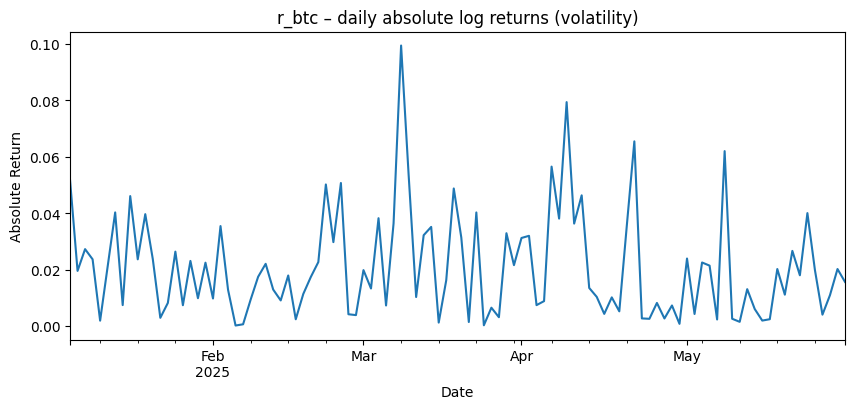

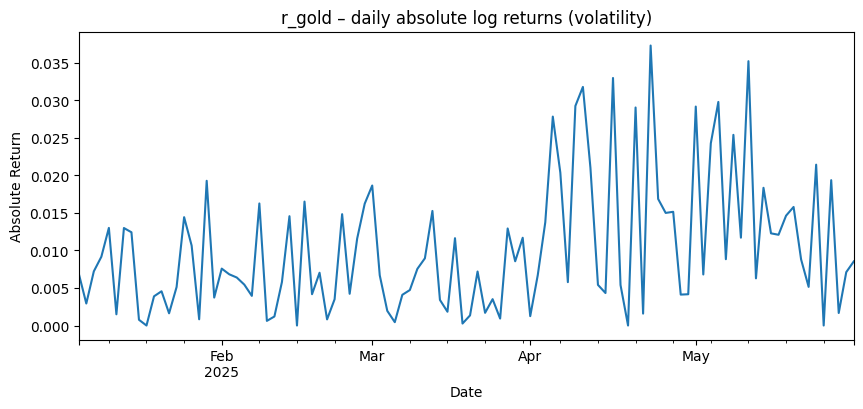

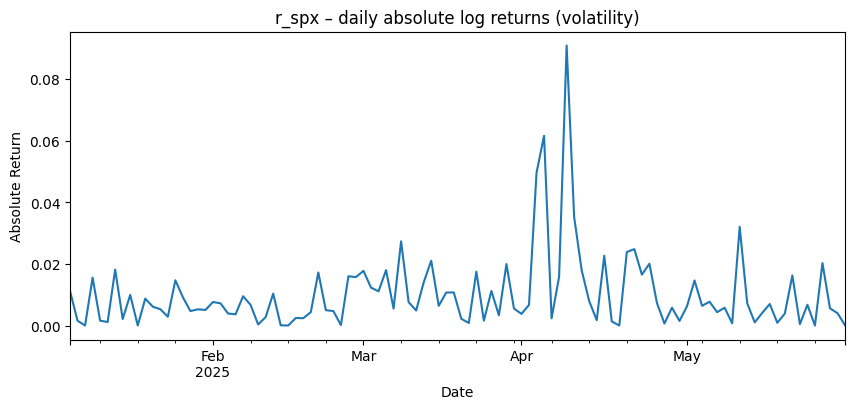

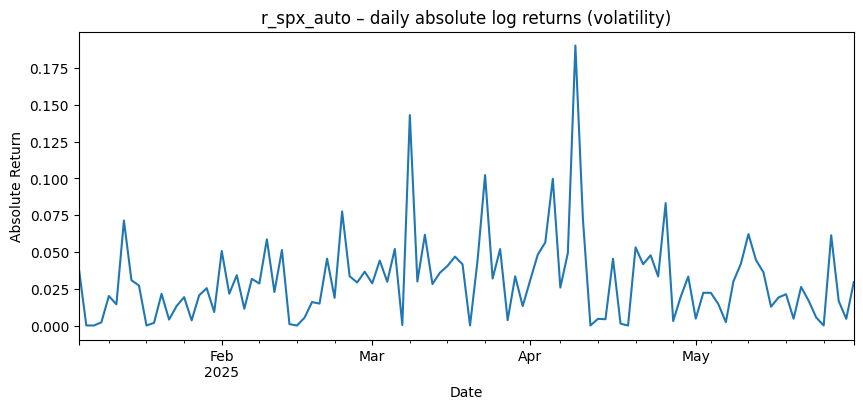

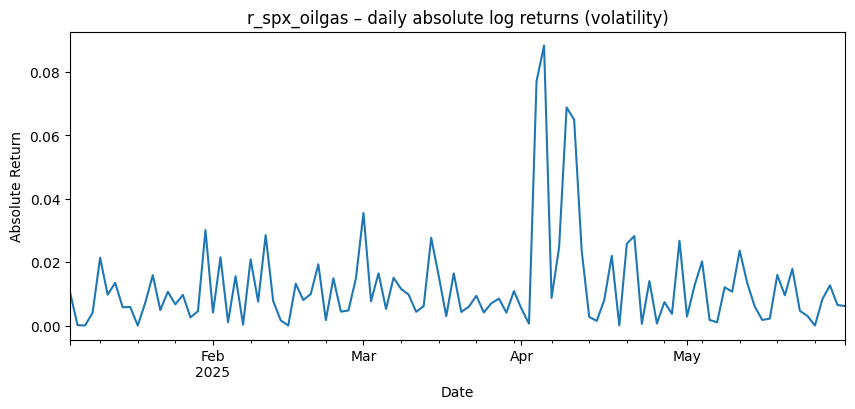

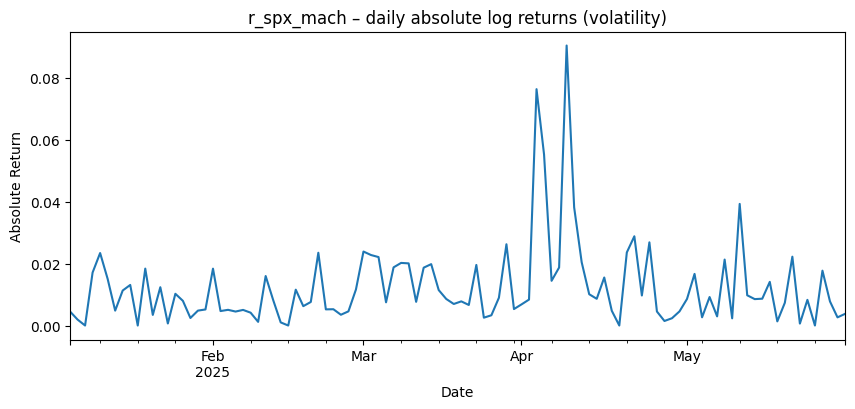

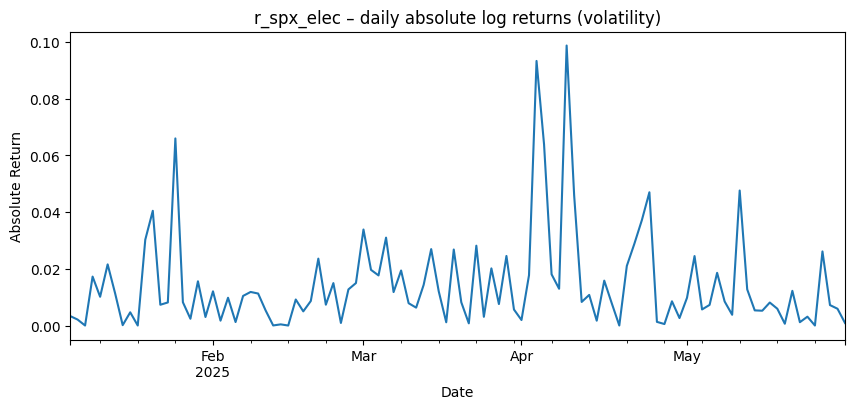

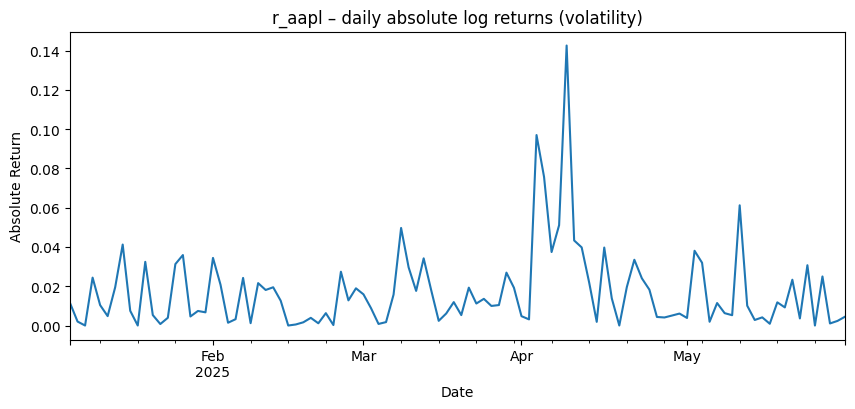

In [18]:
# Plot returns
for col in ["r_btc", "r_gold", "r_spx", "r_spx_auto", "r_spx_oilgas", "r_spx_mach", "r_spx_elec", "r_aapl"]:
    ax = returns[col].plot(title=f"{col} – daily absolute log returns (volatility)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Absolute Return")
    plt.show()


In [19]:
# Summary statistics
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
r_btc,104.0000,0.0209,0.0187,0.0002,0.0071,0.0175,0.0316,0.0994
r_gold,104.0000,0.0102,0.0090,0.0000,0.0039,0.0072,0.0149,0.0373
r_spx,104.0000,0.0101,0.0128,0.0000,0.0024,0.0063,0.0146,0.0909
r_spx_auto,104.0000,0.0309,0.0296,0.0000,0.0108,0.0277,0.0442,0.1902
r_spx_oilgas,104.0000,0.0124,0.0150,0.0000,0.0041,0.0080,0.0156,0.0883
r_spx_mach,104.0000,0.0123,0.0138,0.0000,0.0045,0.0083,0.0179,0.0904
r_spx_elec,104.0000,0.0145,0.0175,0.0000,0.0033,0.0086,0.0182,0.0988
r_aapl,104.0000,0.0172,0.0210,0.0000,0.0039,0.0108,0.0241,0.1426
r_btc_signed,104.0000,0.0002,0.0281,-0.0994,-0.0176,-0.0003,0.0145,0.0794
r_gold_signed,104.0000,0.0021,0.0135,-0.0373,-0.0042,0.0032,0.0090,0.0330


In [20]:
# Correlation matrix
corr = returns[["r_btc", "r_gold", "r_spx", "r_spx_auto", "r_spx_oilgas", "r_spx_mach", "r_spx_elec", "r_aapl"]].corr()
corr


,r_btc,r_gold,r_spx,r_spx_auto,r_spx_oilgas,r_spx_mach,r_spx_elec,r_aapl
r_btc,1.0000,-0.0226,0.3067,0.3548,0.1754,0.2885,0.1786,0.3256
r_gold,-0.0226,1.0000,0.4345,0.2574,0.3242,0.3850,0.3597,0.4227
r_spx,0.3067,0.4345,1.0000,0.7169,0.7556,0.8911,0.8418,0.8328
r_spx_auto,0.3548,0.2574,0.7169,1.0000,0.4724,0.5792,0.5502,0.5868
r_spx_oilgas,0.1754,0.3242,0.7556,0.4724,1.0000,0.7810,0.6836,0.6677
r_spx_mach,0.2885,0.3850,0.8911,0.5792,0.7810,1.0000,0.8227,0.8166
r_spx_elec,0.1786,0.3597,0.8418,0.5502,0.6836,0.8227,1.0000,0.7181
r_aapl,0.3256,0.4227,0.8328,0.5868,0.6677,0.8166,0.7181,1.0000



## 6. Stationarity checks (ADF tests)


In [21]:
def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test for {name}")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print("  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-" * 40)

for col in returns.columns:
    adf_test(returns[col], name=col)

ADF Test for r_btc
  Test statistic: -8.4476
  p-value:        0.0000
  Critical values:
    1%: -3.4955
    5%: -2.8900
    10%: -2.5820
----------------------------------------
ADF Test for r_gold
  Test statistic: -1.8773
  p-value:        0.3428
  Critical values:
    1%: -3.5035
    5%: -2.8935
    10%: -2.5838
----------------------------------------
ADF Test for r_spx
  Test statistic: -3.0090
  p-value:        0.0341
  Critical values:
    1%: -3.4975
    5%: -2.8909
    10%: -2.5824
----------------------------------------
ADF Test for r_spx_auto
  Test statistic: -8.7362
  p-value:        0.0000
  Critical values:
    1%: -3.4955
    5%: -2.8900
    10%: -2.5820
----------------------------------------
ADF Test for r_spx_oilgas
  Test statistic: -3.3662
  p-value:        0.0122
  Critical values:
    1%: -3.4975
    5%: -2.8909
    10%: -2.5824
----------------------------------------
ADF Test for r_spx_mach
  Test statistic: -2.7629
  p-value:        0.0638
  Critical values

## 7. Export dataset
We export a panel containing the returns and control variables for reuse in the emotion/EPI notebook.

In [22]:
panel = returns.copy()

# Optionally include event dummies or other flags
# panel = returns_events

panel.to_parquet(FINANCIAL_PANEL_FILE)
panel.to_csv(FINANCIAL_PANEL_CSV)

print("Saved financial panel to:")
print("  ", FINANCIAL_PANEL_FILE)
print("  ", FINANCIAL_PANEL_CSV)

Saved financial panel to:
   ./data/financial_returns_and_controls.parquet
   ./data/financial_returns_and_controls.csv
